# Merge the three parallel lambda-mix shards

Run this notebook after all three shard notebooks have completed. It combines
their raw tables, verifies that all 900 expected nonlinear trajectories are
present, and produces the final model-specific and common-lambda summaries.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find the repository root containing opinion_dynamics/."
    )


REPO_ROOT = find_repo_root()
STUDY_DATE = "2026_08_01"
BASE_STUDY_NAME = "lambda_mix_sweep_all_dynamics"
NUM_SHARDS = 3

RESULTS_ROOT = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
)

SHARD_DIRS = [
    RESULTS_ROOT
    / (
        f"experiment_{STUDY_DATE}_{BASE_STUDY_NAME}"
        f"_shard_{shard_id}_of_{NUM_SHARDS}"
    )
    for shard_id in range(NUM_SHARDS)
]

for directory in SHARD_DIRS:
    if not directory.exists():
        raise FileNotFoundError(f"Missing shard directory: {directory}")

print("Shard directories:")
for directory in SHARD_DIRS:
    print(" -", directory)

Shard directories:
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_0_of_3
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_1_of_3
 - d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_shard_2_of_3


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_29880\566120671.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def read_required_csv(directory: Path, filename: str) -> pd.DataFrame:
    path = directory / filename
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


summary_df = pd.concat(
    [
        read_required_csv(directory, "lambda_mix_summary.csv")
        for directory in SHARD_DIRS
    ],
    ignore_index=True,
)
trajectory_df = pd.concat(
    [
        read_required_csv(directory, "lambda_mix_trajectories.csv")
        for directory in SHARD_DIRS
    ],
    ignore_index=True,
)
fit_df = pd.concat(
    [
        read_required_csv(directory, "lambda_mix_fit_history.csv")
        for directory in SHARD_DIRS
    ],
    ignore_index=True,
)
run_index_df = pd.concat(
    [
        read_required_csv(directory, "lambda_mix_run_index.csv")
        for directory in SHARD_DIRS
    ],
    ignore_index=True,
)

failure_frames = []
for directory in SHARD_DIRS:
    path = directory / "lambda_mix_failures.csv"
    if path.exists() and path.stat().st_size > 0:
        try:
            frame = pd.read_csv(path)
        except pd.errors.EmptyDataError:
            frame = pd.DataFrame()
        if not frame.empty:
            failure_frames.append(frame)

failure_df = (
    pd.concat(failure_frames, ignore_index=True)
    if failure_frames
    else pd.DataFrame()
)

duplicate_mask = summary_df.duplicated(
    subset=[
        "dynamics",
        "topology_seed",
        "initial_seed",
        "lambda_mix",
    ],
    keep=False,
)
if duplicate_mask.any():
    display(summary_df.loc[duplicate_mask].sort_values(
        ["dynamics", "topology_seed", "initial_seed", "lambda_mix"]
    ))
    raise RuntimeError("Duplicate scientific trial keys found across shards.")

expected_trials = 6 * 6 * 5 * 5
actual_trials = len(summary_df)

print("Expected trials:", expected_trials)
print("Combined trials:", actual_trials)
print("Failures:", len(failure_df))

if actual_trials != expected_trials:
    raise RuntimeError(
        f"Expected {expected_trials} successful trials, found {actual_trials}."
    )
if not failure_df.empty:
    raise RuntimeError("At least one shard contains failed trials.")

display(
    summary_df.groupby(["dynamics", "lambda_mix"])
    .size()
    .unstack(fill_value=0)
)

Expected trials: 900
Combined trials: 900
Failures: 0


lambda_mix,0.00,0.25,0.50,0.70,0.85,1.00
dynamics,,,,,,
coca,25,25,25,25,25,25
friedkinjohnsen,25,25,25,25,25,25
hegselmannkrause,25,25,25,25,25,25
laplacian,25,25,25,25,25,25
nonlinearinfluence,25,25,25,25,25,25
repulsion,25,25,25,25,25,25


In [3]:
def mean_ci95(
    dataframe: pd.DataFrame,
    value_column: str,
    group_columns: list[str],
) -> pd.DataFrame:
    result = (
        dataframe.groupby(group_columns)[value_column]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    result["sem"] = result["std"] / np.sqrt(
        result["count"].clip(lower=1)
    )
    result["ci95"] = 1.96 * result["sem"].fillna(0.0)
    return result


decision_summary = mean_ci95(
    summary_df,
    "model_minus_uniform_mean_end",
    ["dynamics", "dynamics_label", "lambda_mix"],
)

win_rates = (
    summary_df.assign(
        win_vs_uniform=(
            summary_df["model_minus_uniform_mean_end"] > 0
        )
    )
    .groupby(["dynamics", "lambda_mix"])["win_vs_uniform"]
    .mean()
    .rename("win_rate_vs_uniform")
    .reset_index()
)

decision_summary = decision_summary.merge(
    win_rates,
    on=["dynamics", "lambda_mix"],
    how="left",
)

best_by_dynamics = (
    decision_summary.sort_values(
        ["dynamics", "mean", "lambda_mix"],
        ascending=[True, False, True],
    )
    .groupby("dynamics", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(
    best_by_dynamics[
        [
            "dynamics_label",
            "lambda_mix",
            "mean",
            "ci95",
            "win_rate_vs_uniform",
            "count",
        ]
    ]
    .rename(
        columns={
            "lambda_mix": "best_lambda_mix",
            "mean": "mean_gap_vs_uniform",
            "ci95": "gap_ci95",
            "count": "n_trials",
        }
    )
    .round(5)
)

,dynamics_label,best_lambda_mix,mean_gap_vs_uniform,gap_ci95,win_rate_vs_uniform,n_trials
0,COCA,0.00,0.03336,0.00840,0.96,25
1,Friedkin--Johnsen,0.00,-0.09669,0.02654,0.04,25
2,Hegselmann--Krause,0.25,0.00752,0.02868,0.48,25
3,Linear consensus,0.70,0.08398,0.01509,1.00,25
4,Nonlinear influence,0.50,0.01335,0.02194,0.48,25
5,Repulsion,0.50,0.11584,0.03309,1.00,25


In [4]:
global_rows = []

for lambda_mix, group in decision_summary.groupby("lambda_mix"):
    gaps = group["mean"].to_numpy(dtype=float)
    wins = group["win_rate_vs_uniform"].to_numpy(dtype=float)

    global_rows.append(
        {
            "lambda_mix": float(lambda_mix),
            "macro_mean_gap_vs_uniform": float(np.mean(gaps)),
            "macro_median_gap_vs_uniform": float(np.median(gaps)),
            "std_across_dynamics": float(np.std(gaps, ddof=1)),
            "worst_dynamics_gap": float(np.min(gaps)),
            "best_dynamics_gap": float(np.max(gaps)),
            "mean_win_rate_vs_uniform": float(np.mean(wins)),
        }
    )

global_summary = (
    pd.DataFrame(global_rows)
    .sort_values("lambda_mix")
    .reset_index(drop=True)
)

best_average_lambda = float(
    global_summary.sort_values(
        ["macro_mean_gap_vs_uniform", "lambda_mix"],
        ascending=[False, True],
    ).iloc[0]["lambda_mix"]
)

best_worst_case_lambda = float(
    global_summary.sort_values(
        [
            "worst_dynamics_gap",
            "macro_mean_gap_vs_uniform",
            "lambda_mix",
        ],
        ascending=[False, False, True],
    ).iloc[0]["lambda_mix"]
)

display(global_summary.round(5))
print("Best macro-average lambda:", best_average_lambda)
print("Best worst-case lambda:", best_worst_case_lambda)

,lambda_mix,macro_mean_gap_vs_uniform,macro_median_gap_vs_uniform,std_across_dynamics,worst_dynamics_gap,best_dynamics_gap,mean_win_rate_vs_uniform
0,0.00,0.02501,0.02317,0.07218,-0.09669,0.11060,0.65333
1,0.25,0.02504,0.02264,0.07228,-0.09669,0.11157,0.64667
2,0.50,0.02609,0.02317,0.07346,-0.09669,0.11584,0.66000
3,0.70,0.02540,0.02325,0.07240,-0.09669,0.11109,0.66667
4,0.85,0.02570,0.02239,0.07321,-0.09669,0.11469,0.64000
5,1.00,0.02392,0.01868,0.07276,-0.09669,0.11312,0.61333


Best macro-average lambda: 0.5
Best worst-case lambda: 0.5


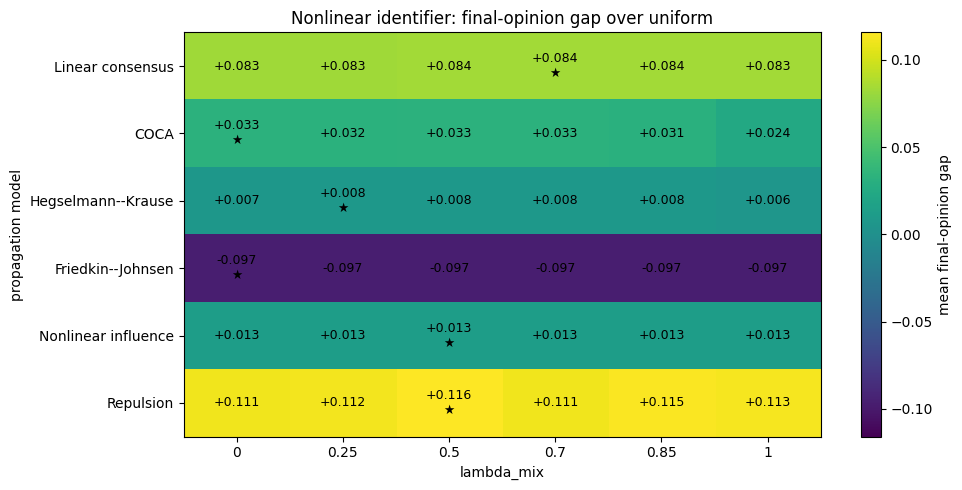

In [5]:
gap_table = (
    decision_summary.pivot(
        index="dynamics_label",
        columns="lambda_mix",
        values="mean",
    )
    .reindex(
        index=[
            "Linear consensus",
            "COCA",
            "Hegselmann--Krause",
            "Friedkin--Johnsen",
            "Nonlinear influence",
            "Repulsion",
        ],
        columns=[0.0, 0.25, 0.5, 0.7, 0.85, 1.0],
    )
)

values = gap_table.to_numpy(dtype=float)
maximum = max(float(np.nanmax(np.abs(values))), 1e-12)

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(
    values,
    aspect="auto",
    vmin=-maximum,
    vmax=maximum,
)
ax.set_title("Nonlinear identifier: final-opinion gap over uniform")
ax.set_xlabel("lambda_mix")
ax.set_ylabel("propagation model")
ax.set_xticks(np.arange(len(gap_table.columns)))
ax.set_xticklabels([f"{value:g}" for value in gap_table.columns])
ax.set_yticks(np.arange(len(gap_table.index)))
ax.set_yticklabels(gap_table.index)

for row_index in range(gap_table.shape[0]):
    row = values[row_index]
    best_column = int(np.nanargmax(row))
    for column_index in range(gap_table.shape[1]):
        value = values[row_index, column_index]
        text = f"{value:+.3f}"
        if column_index == best_column:
            text += "\n★"
        ax.text(
            column_index,
            row_index,
            text,
            ha="center",
            va="center",
            fontsize=9,
        )

fig.colorbar(image, ax=ax, label="mean final-opinion gap")
fig.tight_layout()
plt.show()
plt.close(fig)

In [6]:
pair_keys = [
    "dynamics",
    "dynamics_label",
    "topology_seed",
    "initial_seed",
    "trial_id",
]
reference_lambda = 0.7

reference = (
    summary_df[
        np.isclose(summary_df["lambda_mix"], reference_lambda)
    ][pair_keys + ["mean_end"]]
    .rename(columns={"mean_end": "mean_end_reference"})
)

paired_reference_df = summary_df.merge(
    reference,
    on=pair_keys,
    how="inner",
)
paired_reference_df["gain_vs_reference_lambda"] = (
    paired_reference_df["mean_end"]
    - paired_reference_df["mean_end_reference"]
)

paired_reference_summary = mean_ci95(
    paired_reference_df,
    "gain_vs_reference_lambda",
    ["dynamics", "dynamics_label", "lambda_mix"],
)

display(
    paired_reference_summary.sort_values(
        ["dynamics_label", "lambda_mix"]
    ).round(5)
)

,dynamics,dynamics_label,lambda_mix,mean,std,count,sem,ci95
0,coca,COCA,0.00,0.00021,0.00436,25,0.00087,0.00171
1,coca,COCA,0.25,-0.00084,0.00505,25,0.00101,0.00198
2,coca,COCA,0.50,-0.00016,0.00290,25,0.00058,0.00114
3,coca,COCA,0.70,0.00000,0.00000,25,0.00000,0.00000
4,coca,COCA,0.85,-0.00173,0.00438,25,0.00088,0.00172
5,coca,COCA,1.00,-0.00913,0.01620,25,0.00324,0.00635
6,friedkinjohnsen,Friedkin--Johnsen,0.00,0.00000,0.00000,25,0.00000,0.00000
7,friedkinjohnsen,Friedkin--Johnsen,0.25,0.00000,0.00000,25,0.00000,0.00000
8,friedkinjohnsen,Friedkin--Johnsen,0.50,0.00000,0.00000,25,0.00000,0.00000
9,friedkinjohnsen,Friedkin--Johnsen,0.70,0.00000,0.00000,25,0.00000,0.00000


In [7]:
COMBINED_DIR = (
    RESULTS_ROOT
    / f"experiment_{STUDY_DATE}_{BASE_STUDY_NAME}_combined"
)
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(
    COMBINED_DIR / "lambda_mix_summary.csv",
    index=False,
)
trajectory_df.to_csv(
    COMBINED_DIR / "lambda_mix_trajectories.csv",
    index=False,
)
fit_df.to_csv(
    COMBINED_DIR / "lambda_mix_fit_history.csv",
    index=False,
)
run_index_df.to_csv(
    COMBINED_DIR / "lambda_mix_run_index.csv",
    index=False,
)
decision_summary.to_csv(
    COMBINED_DIR / "lambda_mix_decision_summary.csv",
    index=False,
)
best_by_dynamics.to_csv(
    COMBINED_DIR / "lambda_mix_best_by_dynamics.csv",
    index=False,
)
global_summary.to_csv(
    COMBINED_DIR / "lambda_mix_global_summary.csv",
    index=False,
)
paired_reference_df.to_csv(
    COMBINED_DIR / "lambda_mix_paired_vs_0p7.csv",
    index=False,
)
paired_reference_summary.to_csv(
    COMBINED_DIR / "lambda_mix_paired_vs_0p7_summary.csv",
    index=False,
)

recommendation = {
    "best_macro_average_lambda": best_average_lambda,
    "best_worst_case_lambda": best_worst_case_lambda,
    "reference_lambda": reference_lambda,
    "best_by_dynamics": best_by_dynamics[
        [
            "dynamics",
            "dynamics_label",
            "lambda_mix",
            "mean",
            "ci95",
            "win_rate_vs_uniform",
        ]
    ].to_dict(orient="records"),
}

(
    COMBINED_DIR / "lambda_mix_recommendation.json"
).write_text(
    json.dumps(recommendation, indent=2),
    encoding="utf-8",
)

print("Combined results saved to:", COMBINED_DIR)

Combined results saved to: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_01_lambda_mix_sweep_all_dynamics_combined
